In [1]:
from glob import glob
import pandas as pd
from tqdm.auto import tqdm
from io import StringIO
import subprocess
import shlex
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os

matplotlib.rcParams['font.weight'] = "medium"
matplotlib.rcParams['axes.labelweight'] = 'medium'
matplotlib.rcParams['figure.titleweight'] = 'medium'
matplotlib.rcParams['axes.titleweight'] = 'medium'
sns.set_style('whitegrid')
sns.set(font_scale=1.1, style="ticks", font="lato")
HIT_THR = 0.0005

os.chdir('/home/vladimirnoz/Projects/Codebook_Perspectives/Chromatin/')

In [2]:
rsid = 'rs2286729'
tf = 'ZNF70'
path_to_motif_tables = glob(f'as_tables/{tf}@*.tsv')
if tf == 'SP140+SP140L':
    path_to_motif_tables = (
        glob(f'as_tables/SP140@*.tsv') 
        + glob(f'as_tables/SP140L@*.tsv')
    )
    

tables = []
for path in tqdm(path_to_motif_tables):
    table = pd.read_table(path)
    sample = path.split('/')[-1].split('.')[0].split('@')
    sample = '@'.join(sample[1:])
    table['cell_type'] = sample
    table['TF'] = path.split('/')[-1].split('@')[0]
    tables.append(table)
df = pd.concat(tables)

  0%|          | 0/898 [00:00<?, ?it/s]

In [3]:
mask = (df['id'] == rsid) * (df['fdr_comb_pval'] < 0.05)
df = df[mask]

In [4]:
good_ct = glob('agg_*/pvalues_init.tsv')
good_ct = pd.concat(pd.read_table(x) for x in good_ct)
if tf == 'SP140+SP140L':
    ct_mask = (good_ct['sample'].isin(df['cell_type'])) * (good_ct['TF'].isin(['SP140', 'SP140L']))
else:
    ct_mask = (good_ct['sample'].isin(df['cell_type'])) * (good_ct['TF'] == tf)
good_ct = set(good_ct[ct_mask]['sample'])

In [5]:
df

,#chr,start,end,mean_bad,id,max_cover,ref,alt,n_reps,ref_comb_es,...,ref_motif_pos,ref_motif_orient,alt_motif_pos,alt_motif_orient,ref_motif_pval,alt_motif_pval,motif_fc,motif_conc,cell_type,TF
19857,chr12,6764651,6764652,1.000000,rs2286729,196,G,A,1,0.917811,...,-6,direct,-6,direct,0.000086,0.002243,-4.699372,Concordant,atac@macula_of_retina,ZNF70
24425,chr12,6764651,6764652,1.428571,rs2286729,389,G,A,14,1.019917,...,-6,direct,-6,direct,0.000086,0.002243,-4.699372,Concordant,dnase@skin_fibroblast,ZNF70
43047,chr12,6764651,6764652,1.222220,rs2286729,459,G,A,3,0.499927,...,-6,direct,-6,direct,0.000086,0.002243,-4.699372,Concordant,dnase@brain,ZNF70


In [6]:
#tf = 'SP140L'

In [7]:
df[df['cell_type'].isin(good_ct)]

,#chr,start,end,mean_bad,id,max_cover,ref,alt,n_reps,ref_comb_es,...,ref_motif_pos,ref_motif_orient,alt_motif_pos,alt_motif_orient,ref_motif_pval,alt_motif_pval,motif_fc,motif_conc,cell_type,TF
19857,chr12,6764651,6764652,1.00000,rs2286729,196,G,A,1,0.917811,...,-6,direct,-6,direct,0.000086,0.002243,-4.699372,Concordant,atac@macula_of_retina,ZNF70
43047,chr12,6764651,6764652,1.22222,rs2286729,459,G,A,3,0.499927,...,-6,direct,-6,direct,0.000086,0.002243,-4.699372,Concordant,dnase@brain,ZNF70


In [8]:
pos = df.iloc[1, 0:3]
pos = '\t'.join(str(x) for x in pos)
pos

'chr12\t6764651\t6764652'

In [9]:
#test_peaks = glob(f'/home/vladimirnoz/peaks/chipseq_new/*_ZNF70_*')
#test_peaks

In [10]:
tf = 'ZNF70'
peaks = f'/home/vladimirnoz/Projects/Codebook_Perspectives/peaks/chipseq+ghtselex/{tf}.bed'
#peaks = f'/home/vladimirnoz/peaks/chipseq+ghtselex/SP140L.bed'
#peaks = test_peaks[1]
cmd = f'bedtools intersect -a {peaks} -b stdin -wa'
cmd = shlex.split(cmd)
coords = subprocess.run(cmd, input=pos, capture_output=True, text=True).stdout
coords = coords.strip().split('\t')
coords[1], coords[2] = int(coords[1]) + 1, int(coords[2])
peak_padding = (2500 - 602)//2
region = f'{coords[0]}:{coords[1] - peak_padding}-{coords[2] + peak_padding}'

In [11]:
peak_padding

949

In [12]:
chipseq_bam = glob(f'/home/vladimirnoz/Projects/Codebook_Perspectives/SNP_Calling/chipseq/mapped_filtered_reads_??/{tf}.*.bam')
selex_bam = glob(f'/home/vladimirnoz/Projects/Codebook_Perspectives/SNP_Calling/selex/mapped_filtered_reads/{tf}.*.bam')
bams = chipseq_bam

In [13]:
coverage = {}
for bam in tqdm(bams):
    cmd = f'samtools depth -a -r {region} {bam}'
    cmd = shlex.split(cmd)
    print(cmd)
    proc = subprocess.run(cmd, capture_output=True, text=True)
    print(proc.stderr)
    table = proc.stdout
    table = pd.read_table(StringIO(table), names=['#chr', 'pos', 'coverage'])
    coverage[bam.split('/')[-1]] = table
num = len(coverage)

  0%|          | 0/2 [00:00<?, ?it/s]

['samtools', 'depth', '-a', '-r', 'chr12:6763260-6765759', '/home/vladimirnoz/Projects/Codebook_Perspectives/SNP_Calling/chipseq/mapped_filtered_reads_pe/ZNF70.THC_0686.bam']

['samtools', 'depth', '-a', '-r', 'chr12:6763260-6765759', '/home/vladimirnoz/Projects/Codebook_Perspectives/SNP_Calling/chipseq/mapped_filtered_reads_pe/ZNF70.THC_0782.bam']



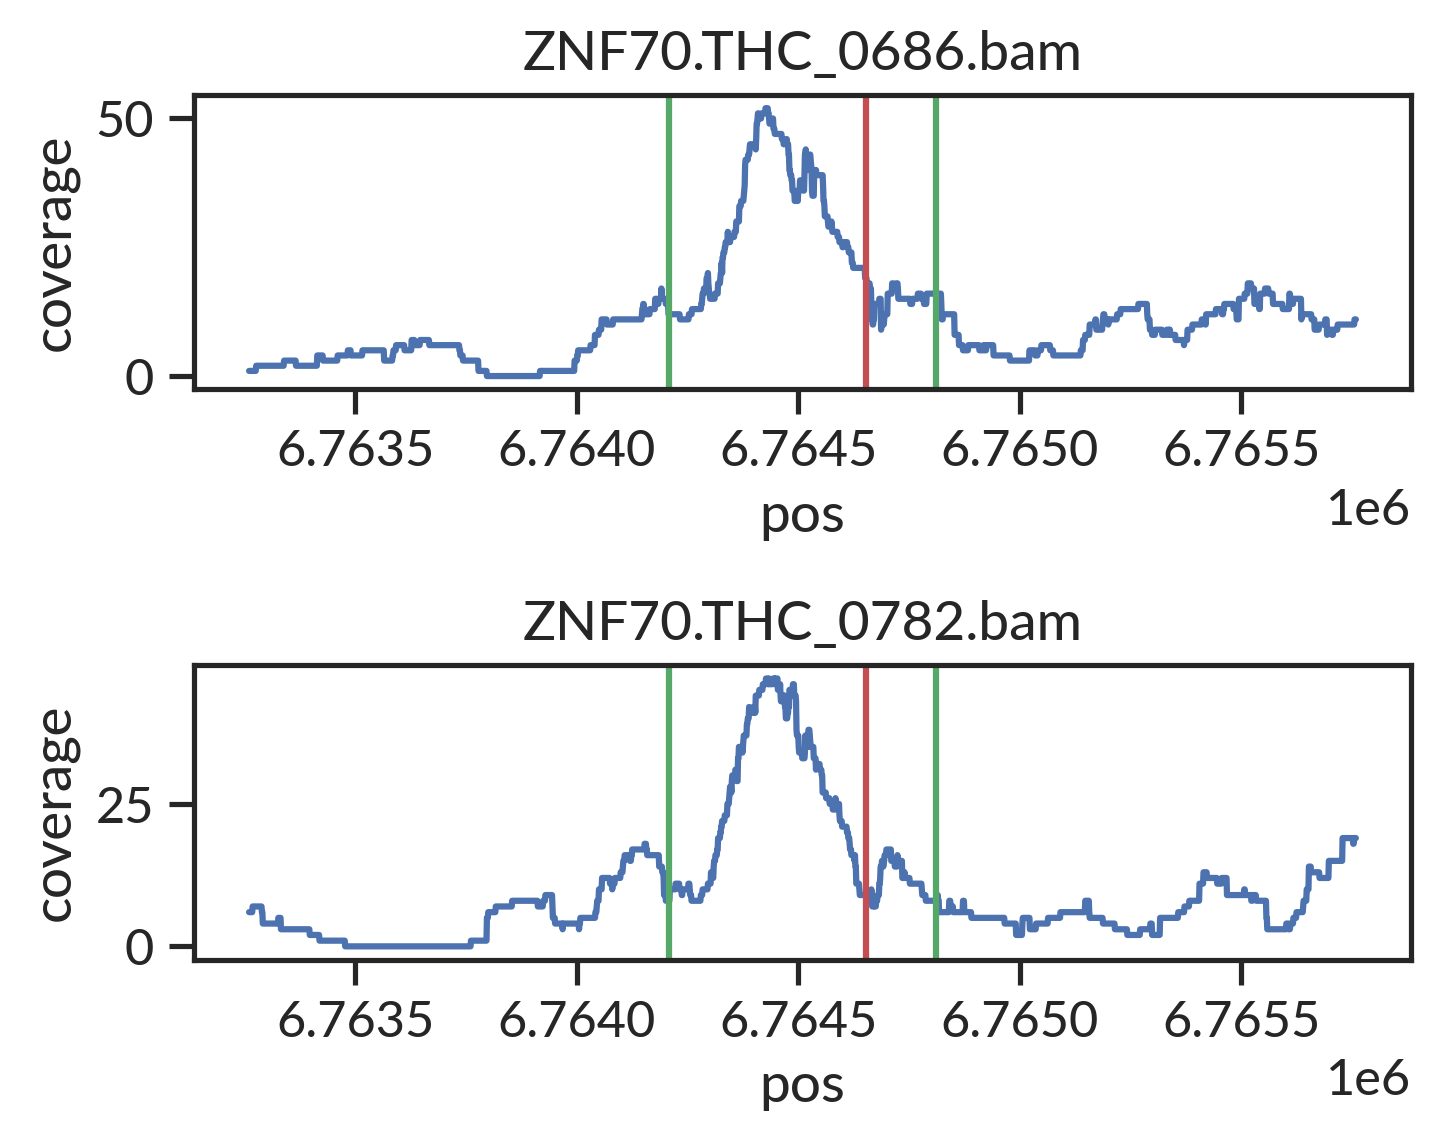

In [14]:
fig, ax = plt.subplots(nrows=num, figsize=(5, 2*num), dpi=300)



for i, (key, item) in enumerate(coverage.items()):
    ax[i].plot(item['pos'], item['coverage'])
    ax[i].axvline(x=df.iloc[0,2], color='r')
    ax[i].axvline(x=coords[1], color='g')
    ax[i].axvline(x=coords[2], color='g')
    ax[i].set_title(key)
    ax[i].set_xlabel('pos')
    ax[i].set_ylabel('coverage')
fig.tight_layout()

# Part 2 Plots

In [15]:
from itertools import product
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO, StringIO
import numpy as np
from matplotlib import font_manager
font_files = font_manager.findSystemFonts(fontpaths='/home/vladimirnoz/Projects/Codebook_Perspectives/fonts')
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

In [16]:
readcounts = {
'dnase@skin_fibroblast': '''DEXP000649	14	11	1	0.22	0.55
DEXP000658	13	7	3/2	0.28	0.84
DEXP000739	18	9	3/2	0.32	0.70
DEXP001855	42	22	3/2	0.04	0.42
DEXP000176	178	97	3/2	4.4·10-4	0.09
DEXP001856	38	22	3/2	0.08	0.40
DEXP000833	17	7	1	0.02	0.94
DEXP000526	290	99	3/2	3.1·10-13	0.93
DEXP001473	14	6	3/2	0.24	0.94
DEXP001853	44	20	3/2	0.16	0.52
DEXP000168	246	117	3/2	6.1·10-7	0.17
DEXP001478	10	7	3/2	0.35	0.74
DEXP001857	36	23	3/2	0.12	0.51
DEXP000752	219	101	3/2	1.5·10-6	0.26''',
'dnase@brain': '''DEXP000229_1	283	176	4/3	2.4·10-4	0.14
DEXP000755_1	212	147	4/3	0.01	0.44
DEXP000256	11	9	1	0.30	0.55''',
'atac@macula_of_retina': '''AEXP003523	126	70	1	4.8·10-5	1.00'''}
for key, item in readcounts.items():
    temp_table = pd.read_table(StringIO(item), header=None)
    readcounts[key] = temp_table[1].sum(), temp_table[2].sum()
readcounts

{'dnase@skin_fibroblast': (np.int64(1179), np.int64(548)),
 'dnase@brain': (np.int64(506), np.int64(332)),
 'atac@macula_of_retina': (np.int64(126), np.int64(70))}

In [17]:
pd.DataFrame(readcounts)

,dnase@skin_fibroblast,dnase@brain,atac@macula_of_retina
0,1179,506,126
1,548,332,70


In [18]:
df['TF'] = tf
df

,#chr,start,end,mean_bad,id,max_cover,ref,alt,n_reps,ref_comb_es,...,ref_motif_pos,ref_motif_orient,alt_motif_pos,alt_motif_orient,ref_motif_pval,alt_motif_pval,motif_fc,motif_conc,cell_type,TF
19857,chr12,6764651,6764652,1.000000,rs2286729,196,G,A,1,0.917811,...,-6,direct,-6,direct,0.000086,0.002243,-4.699372,Concordant,atac@macula_of_retina,ZNF70
24425,chr12,6764651,6764652,1.428571,rs2286729,389,G,A,14,1.019917,...,-6,direct,-6,direct,0.000086,0.002243,-4.699372,Concordant,dnase@skin_fibroblast,ZNF70
43047,chr12,6764651,6764652,1.222220,rs2286729,459,G,A,3,0.499927,...,-6,direct,-6,direct,0.000086,0.002243,-4.699372,Concordant,dnase@brain,ZNF70


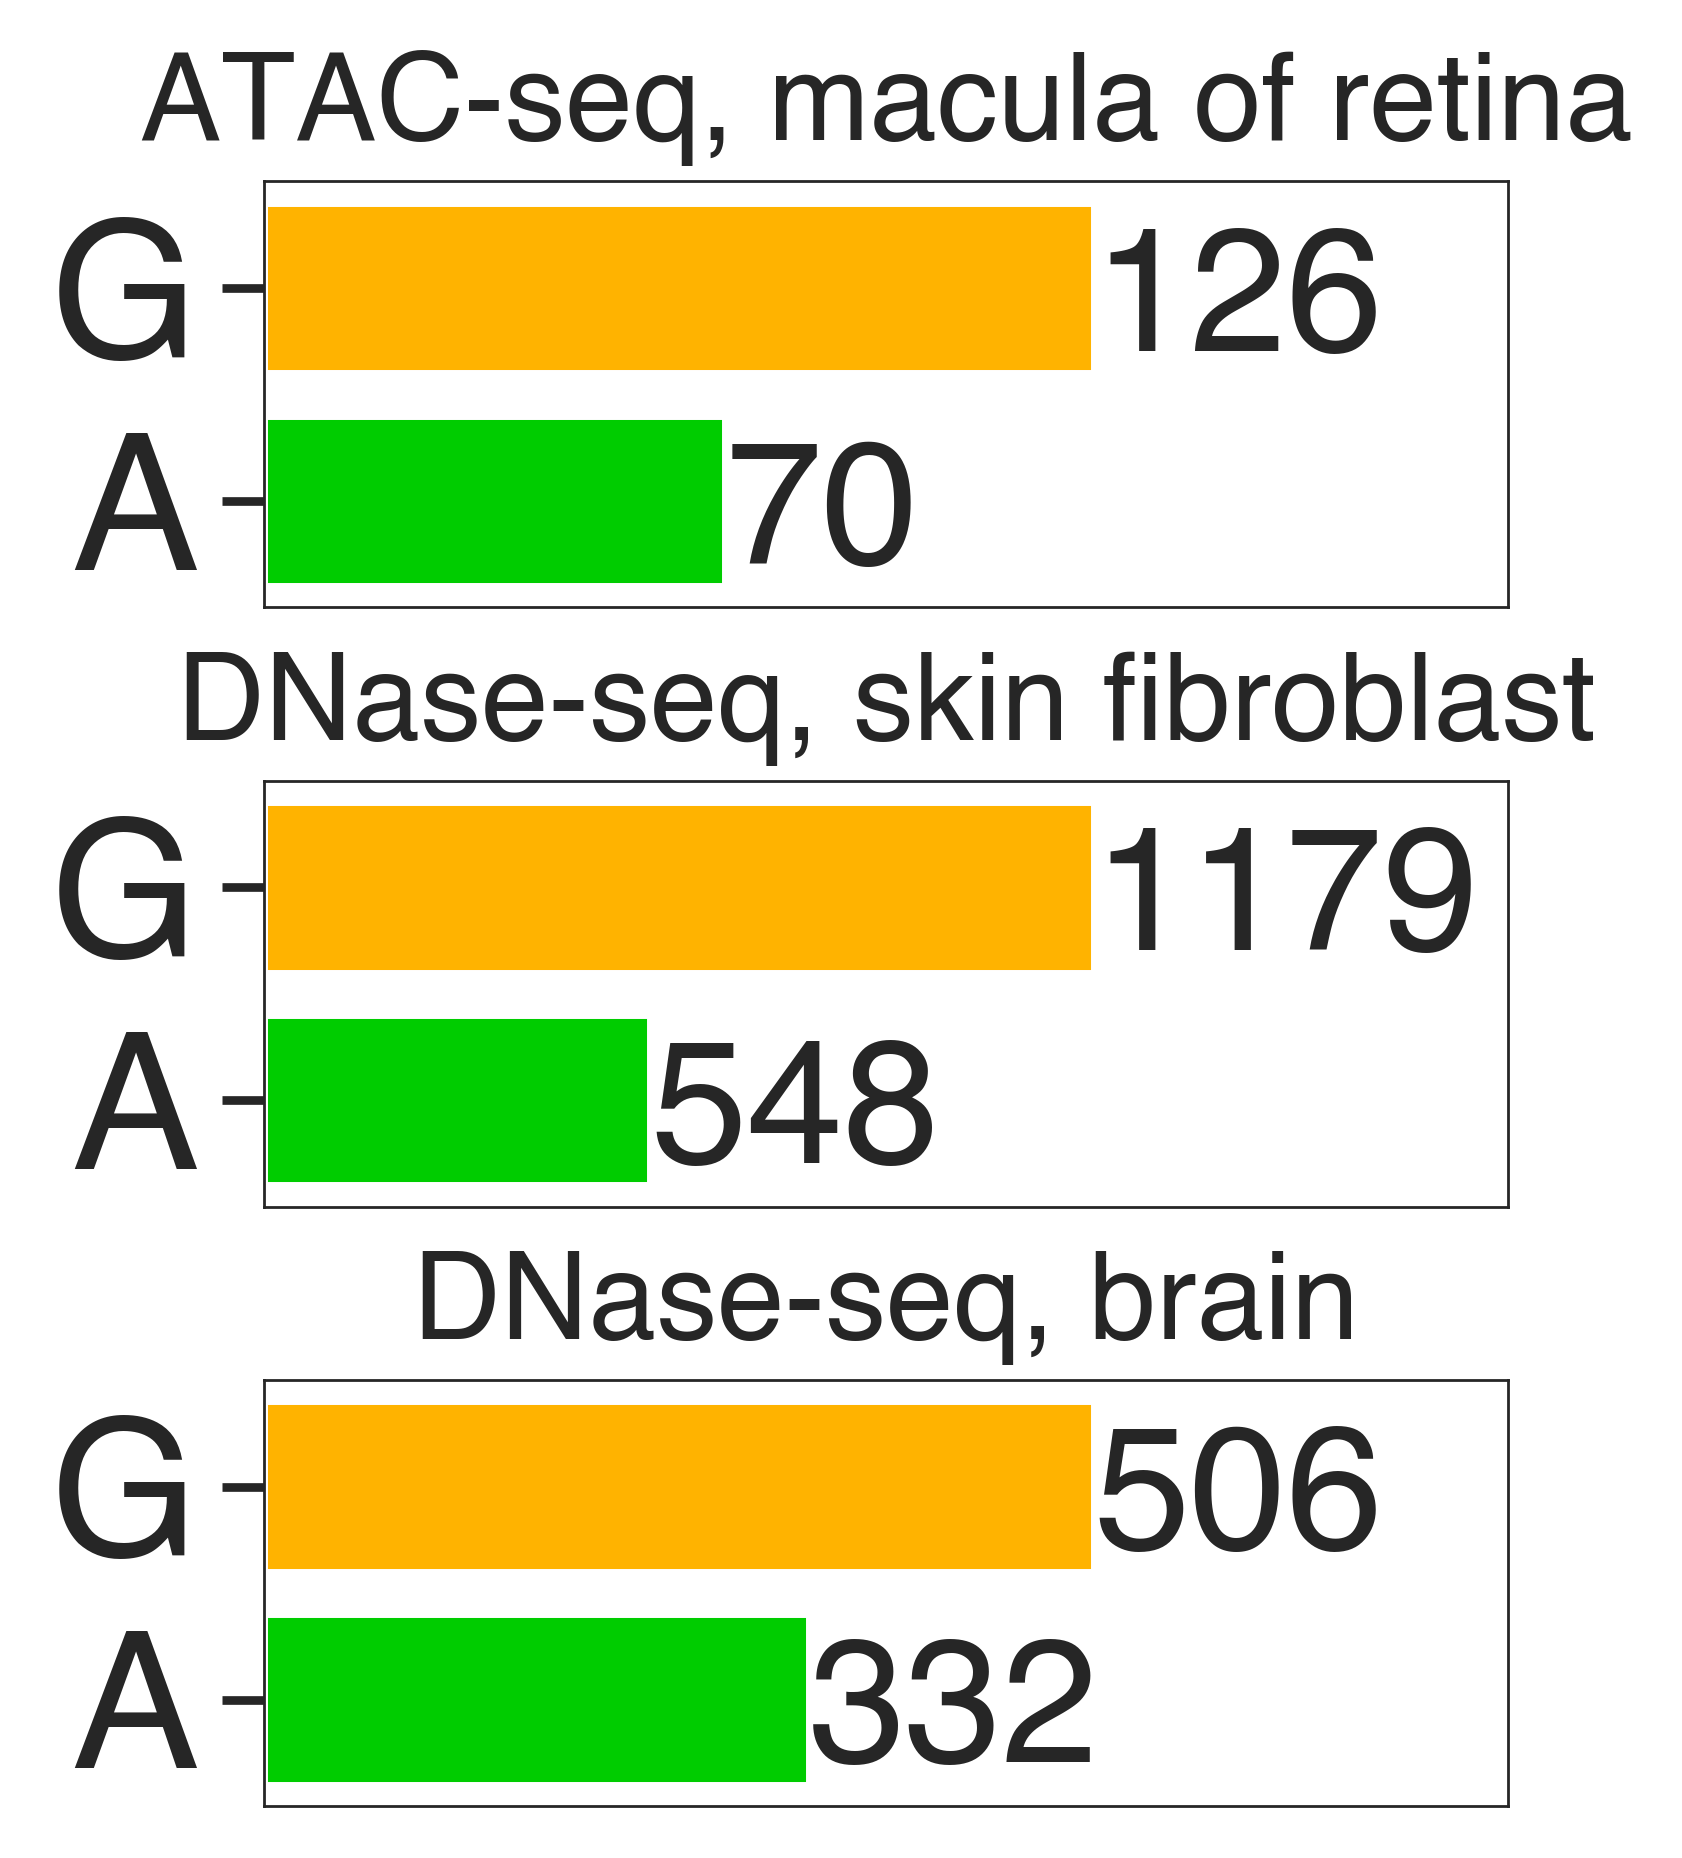

In [19]:
def get_title(cell_type):
    s = cell_type.replace('atac', 'ATAC-seq')
    s = s.replace('dnase', 'DNase-seq')
    s = s.replace('@', ', ')
    s = s.replace('_', ' ')
    return s

palette = {'T': '#7900C8', 'C': "#FFA500", 'G': '#FFB300', 'A': '#0C0'}

sns.set(font_scale=2.5, style="ticks", font="helvetica")
TEXTSIZE=25

fig, axs = plt.subplots(nrows=len(df), figsize=(3, 1.2*len(df)), dpi=500, constrained_layout = True)
for ax, spine in product(axs, ['top', 'bottom', 'right', 'left']):
    ax.spines[spine].set_linewidth(0.4)

xlim=pd.DataFrame(readcounts).max().max()

for i, (_, row) in enumerate(df.iterrows()):
    es = 2**row['comb_es']
    bar_heights = [0.9, 0.9/es]
    if row['pref_allele'] == 'alt':
        bar_heights = bar_heights[::-1]
    x = [row['ref'], row['alt']]
    y = readcounts[row['cell_type']]
    sns.barplot(x=y, y=x, hue=x, palette=[palette[x[0]], palette[x[1]]], ax=axs[i], saturation=1)
    axs[i].set_xticks([])
    axs[i].set_title(get_title(row['cell_type']), fontdict={'size': TEXTSIZE*0.7})
    axs[i].text(y[0], 0, f'{y[0]}', 
            horizontalalignment='left', 
            verticalalignment='center_baseline',
            fontdict={'size': TEXTSIZE})
    axs[i].text(y[1], 1, f'{y[1]}', 
            horizontalalignment='left', 
            verticalalignment='center_baseline', 
            fontdict={'size': TEXTSIZE})
    axs[i].set_xlim(0, max(y)*1.5)

barplots = BytesIO()
plt.savefig(barplots, bbox_inches='tight')

In [20]:
snptable = df.copy()
tf = 'ZNF70'
tfname = tf
motif_length = len(open(f'/home/vladimirnoz/Projects/Codebook_Perspectives/motifs/manual_motifs_v2/pwms/{tf}.pwm').readlines())-2
print(motif_length)


tfrow = snptable.iloc[0]
if tfrow['ref_motif_pval'] < tfrow['alt_motif_pval']:
    motif_pos = tfrow['ref_motif_pos']
    orient = tfrow['ref_motif_orient']
else:
    motif_pos = tfrow['ref_motif_pos']
    orient = tfrow['ref_motif_orient']
if orient == 'direct':
    logo_path = glob(f'/home/vladimirnoz/Projects/Codebook_Perspectives/motifs/manual_motifs_v2/logos/{tf}_*_logo.png')[0]
else:
    logo_path = glob(f'/home/vladimirnoz/Projects/Codebook_Perspectives/motifs/manual_motifs_v2/logos/{tf}_*_logo_REV.png')[0]

N = 3
motif_left, SHIFT = abs(motif_pos), abs(motif_pos) + N
motif_right, SHIFT_END = motif_length - abs(motif_pos) - 1, motif_length - abs(motif_pos) - 1 + N


snpbed = snptable.iloc[0, 0:3]
snpbed['start'] -= SHIFT
snpbed['end'] += SHIFT_END
snpbed = f'{snpbed["#chr"]}\t{snpbed["start"]}\t{snpbed["end"]}'
GENOME = '/sandbox/buyanchik/genome/GRCh38.primary_assembly.genome.fa'
snpid = rsid
command = shlex.split(f'bedtools getfasta -fi {GENOME} -bed stdin')
seq = subprocess.run(command, input=snpbed, text=True, capture_output=True).stdout.splitlines()[-1]
seq

6


'GATGGGGAGGGA'

In [21]:
def get_bed_from_region(region):
    ch, co = region.split(':')
    st, en = co.split('-')
    bed = f'{ch}\t{st}\t{en}'
    return bed

command = f'bedtools getfasta -fi {GENOME} -bed stdin > /tmp/region.fasta'
subprocess.run(command, input=get_bed_from_region(region), shell=True, text=True)

pwm_path = f'/home/vladimirnoz/Projects/Codebook_Perspectives/motifs/manual_motifs_v2/pwms/{tfname}.pwm'
thr_path = f'/home/vladimirnoz/Projects/Codebook_Perspectives/motifs/manual_motifs_v2/uniform_thrs/{tfname}.thr'
fasta_path = '/tmp/region.fasta'
command = f'bash /home/vladimirnoz/codebook_chrom/scripts/sarus/start_sarus.sh {fasta_path} {pwm_path} {thr_path}'

output = subprocess.run(command, shell=True, capture_output=True, text=True).stdout

motif_hits = pd.read_table(StringIO(output), skiprows=1, names=['score', 'pos', 'st'])
motif_hits = sorted(motif_hits.query(f'score < {HIT_THR}')['pos'])

In [22]:
region

'chr12:6763260-6765759'

In [23]:
def get_conservation(region):
    ch, co = region.split(':')
    st, en = co.split('-')
    prog = '/home/vladimirnoz/phastcons100way/bigWigToBedGraph'
    inp = '/home/vladimirnoz/phastcons100way/hg38.phastCons100way.bw'
    command = f'{prog} -chrom={ch} -start={st} -end={en} {inp} /tmp/tmp.bedGraph && cat /tmp/tmp.bedGraph'
    conservation = subprocess.run(command, shell=True, capture_output=True, text=True).stdout
    conservation = pd.read_table(StringIO(conservation), names=['#chr', 'start', 'pos', 'score'])
    cons_dict = defaultdict(int)
    for _, row in conservation.iterrows():
        cons_dict[row['pos']] = float(row['score'])
    cons_list = []
    for i in range(int(st), int(en)):
        cons_list.append(float(cons_dict[i]))
    return cons_list

conservation = get_conservation(region)

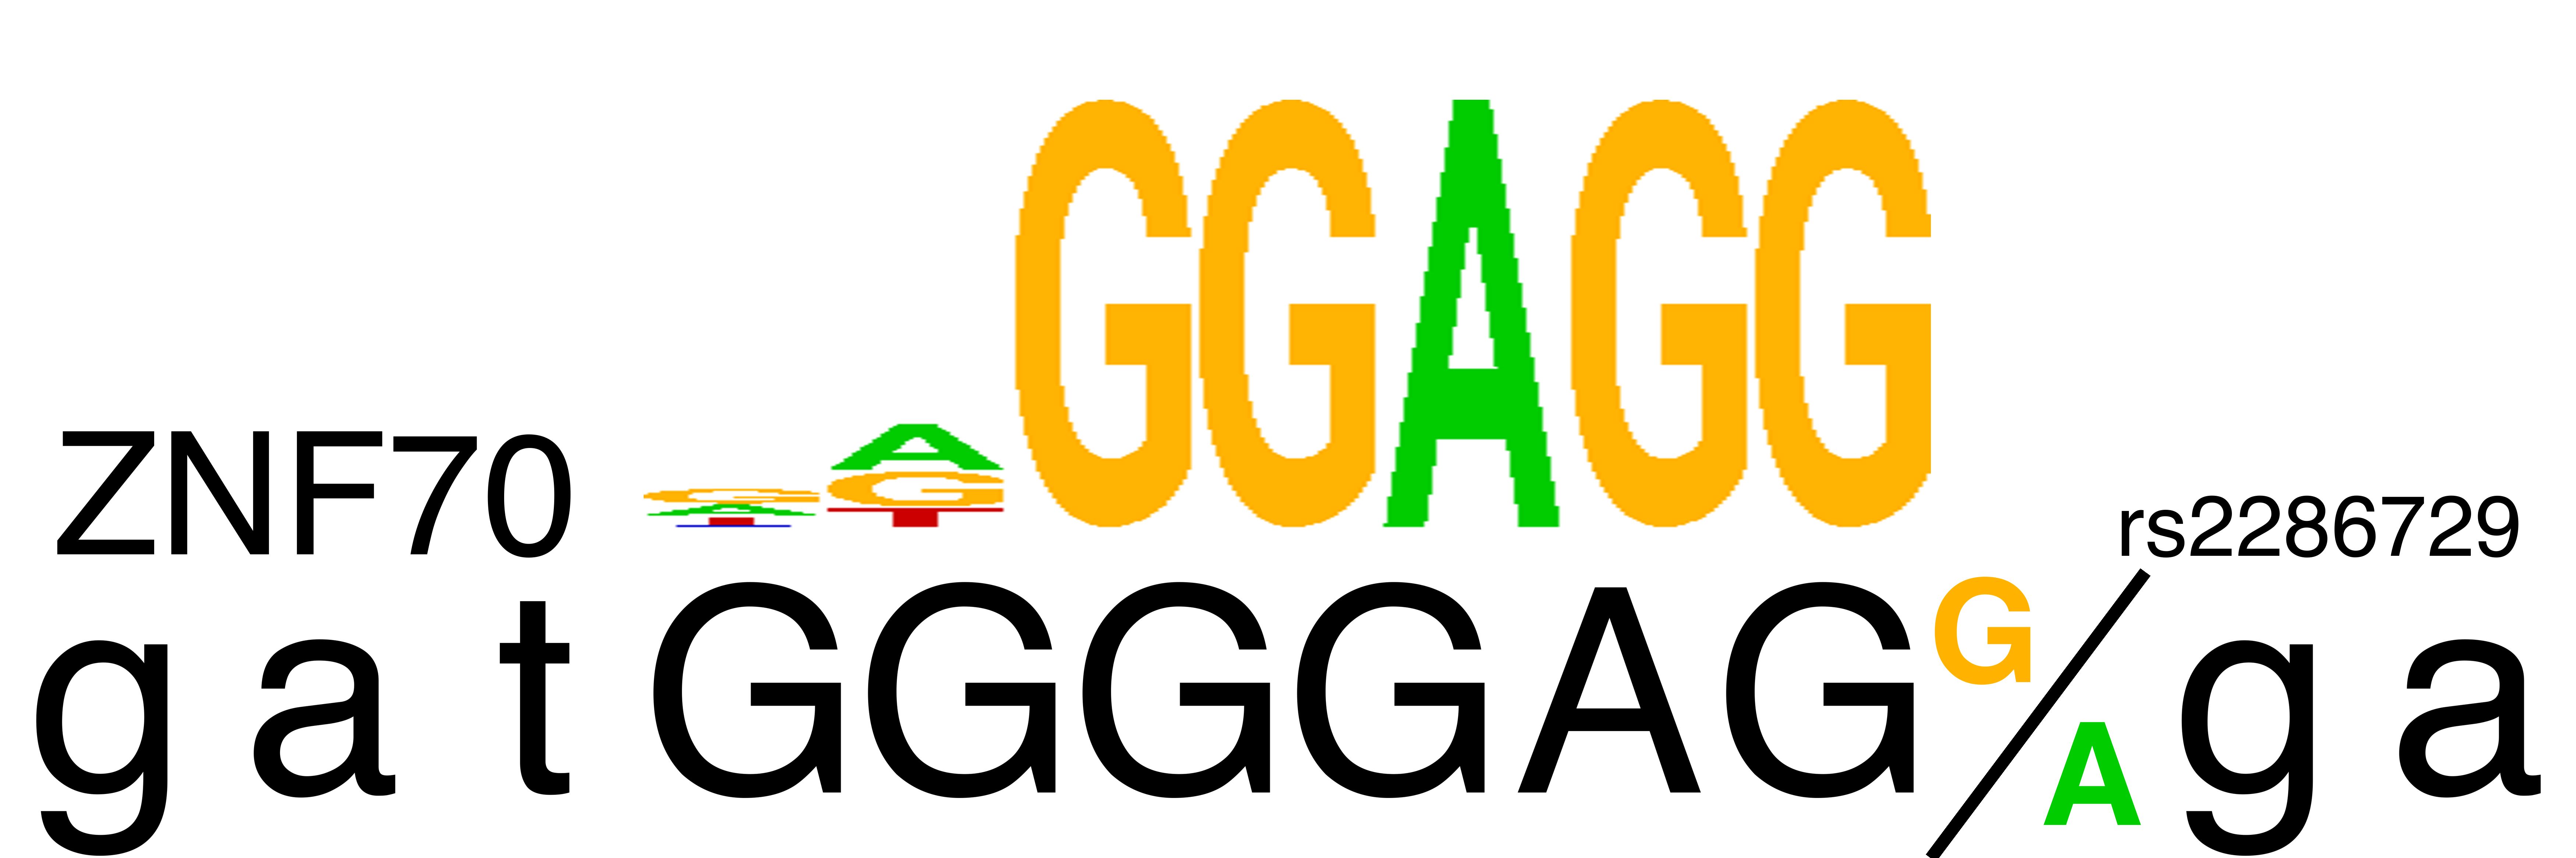

In [24]:
def letters_dict(alphabet, palette=None, style='Regular'):
    letters = {}
    for i, s in enumerate(alphabet):
        w, h = 750, 1000
        img = Image.new(size=(w, h), mode='RGBA', color=(0, 0, 0, 0))
        font = ImageFont.truetype(f'/home/vladimirnoz/Projects/Codebook_Perspectives/fonts/Helvetica-{style}.ttf', size=1000)
        bbox = font.getbbox(s)
        length = bbox[2] - bbox[0]
        height = bbox[3] - bbox[1]
        res_x = (w - length)/2
        res_y = (h - height)/2
        posX = w//2
        posY = h//2
        draw = ImageDraw.Draw(img)
        if palette is None:
            color = 'black'
        else:
            color = palette[s]
        draw.text((posX, posY), s, font=font, fill=color, anchor='mm')
        letters[s] = img
    return letters

    

letters = letters_dict('ATGC')
letters_small = letters_dict('agct')
palette = {'T': '#7900C8', 'C': "#FFA500", 'G': '#FFB300', 'A': '#0C0'}
letters_colored = letters_dict('ATGC', palette=palette, style='Bold')


w = 7000
barplots_image = Image.open(barplots)
barplots_X = w
barplots_Y = barplots_image.size[1]/barplots_image.size[0] * w

letter_w = int(w/len(seq))
letter_h = int(letter_w/letters['A'].size[0] * letters['A'].size[1])
h = letter_h * 3
h = int(h)
main_img = Image.new(size=(w, h), mode='RGBA', color=(255, 255, 255, 255))
draw = ImageDraw.Draw(main_img)
letterY = h - 1*letter_h
hit = snptable[['ref_motif_pval', 'alt_motif_pval']].iloc[0].min() < 0.0005
for i, s in enumerate(seq):
    if i == SHIFT:
        continue
    if (i > SHIFT - motif_left - 1) and (i < SHIFT + motif_right + 1) and hit:
        letter_img = letters[s]
    else:
        letter_img = letters_small[s.lower()]
    x = letter_w * i
    y = letterY
    bbox = (x, y, x+letter_w, y+letter_h)
    main_img.alpha_composite(letter_img.resize((letter_w, letter_h)), (x, y))


barplots_image = barplots_image.resize((int(barplots_X), int(barplots_Y)))
#main_img.alpha_composite(barplots_image, (0, 0))

x = letter_w*SHIFT
y = letterY
#draw.rectangle((x, y, x+letter_w, y+letter_h), fill='black')
bbox = (x, y, x+letter_w//2, y+letter_h//2)
if snptable.iloc[0]['fdr_comb_pval'] < 0.05:
    bar_heights = [0.2, 0.8]
else:
    bar_heights = [0.8, 0.75]
es = 2**snptable['comb_es'].iloc[0]
bar_heights = [0.9, 0.9/es]
for i, allele in enumerate(['ref', 'alt']):
    s = snptable[allele].iloc[0]
    letter_img = letters_colored[s]
    posX, posY = x + i * letter_w/2, y + i * letter_h/2
    main_img.alpha_composite(letter_img.resize((int(letter_w*0.5), int(letter_h*0.5))), (int(posX), int(posY)))

draw.line((x, y+letter_h, x+letter_w, y), fill='black', width=int(letter_w*0.06))


for tf in snptable.iterrows():
    logo = Image.open(logo_path).convert('RGBA')
    if not hit:
        logo = logo.convert('LA').convert('RGBA')
    logo_length = logo.size[0]/100
    logo_w = motif_length*letter_w
    logo_h = letter_w*2
    logo_w, logo_h = int(logo_w), int(logo_h)
    logo = logo.resize((logo_w, logo_h))
    x = (letter_w*(SHIFT+motif_pos))
    y = int(h-1.15*letter_h-(i*logo_h))
    main_img.alpha_composite(logo, (x, y))
font = ImageFont.truetype(f'/home/vladimirnoz/Projects/Codebook_Perspectives/fonts/Helvetica.ttf', size=int(letter_w*0.4))
x = font.getlength(snpid)
draw.text((w-x-letter_w//4, int(h-1.05*letter_h)), snpid, font=font, fill='black', anchor='lb')

font = ImageFont.truetype(f'/home/vladimirnoz/Projects/Codebook_Perspectives/fonts/Helvetica.ttf', size=int(letter_w*0.8))
draw.text((letter_w//4, int(h-1.05*letter_h)), tfname, font=font, fill='black', anchor='lb')


main_img

(0, 17, 400, 190)


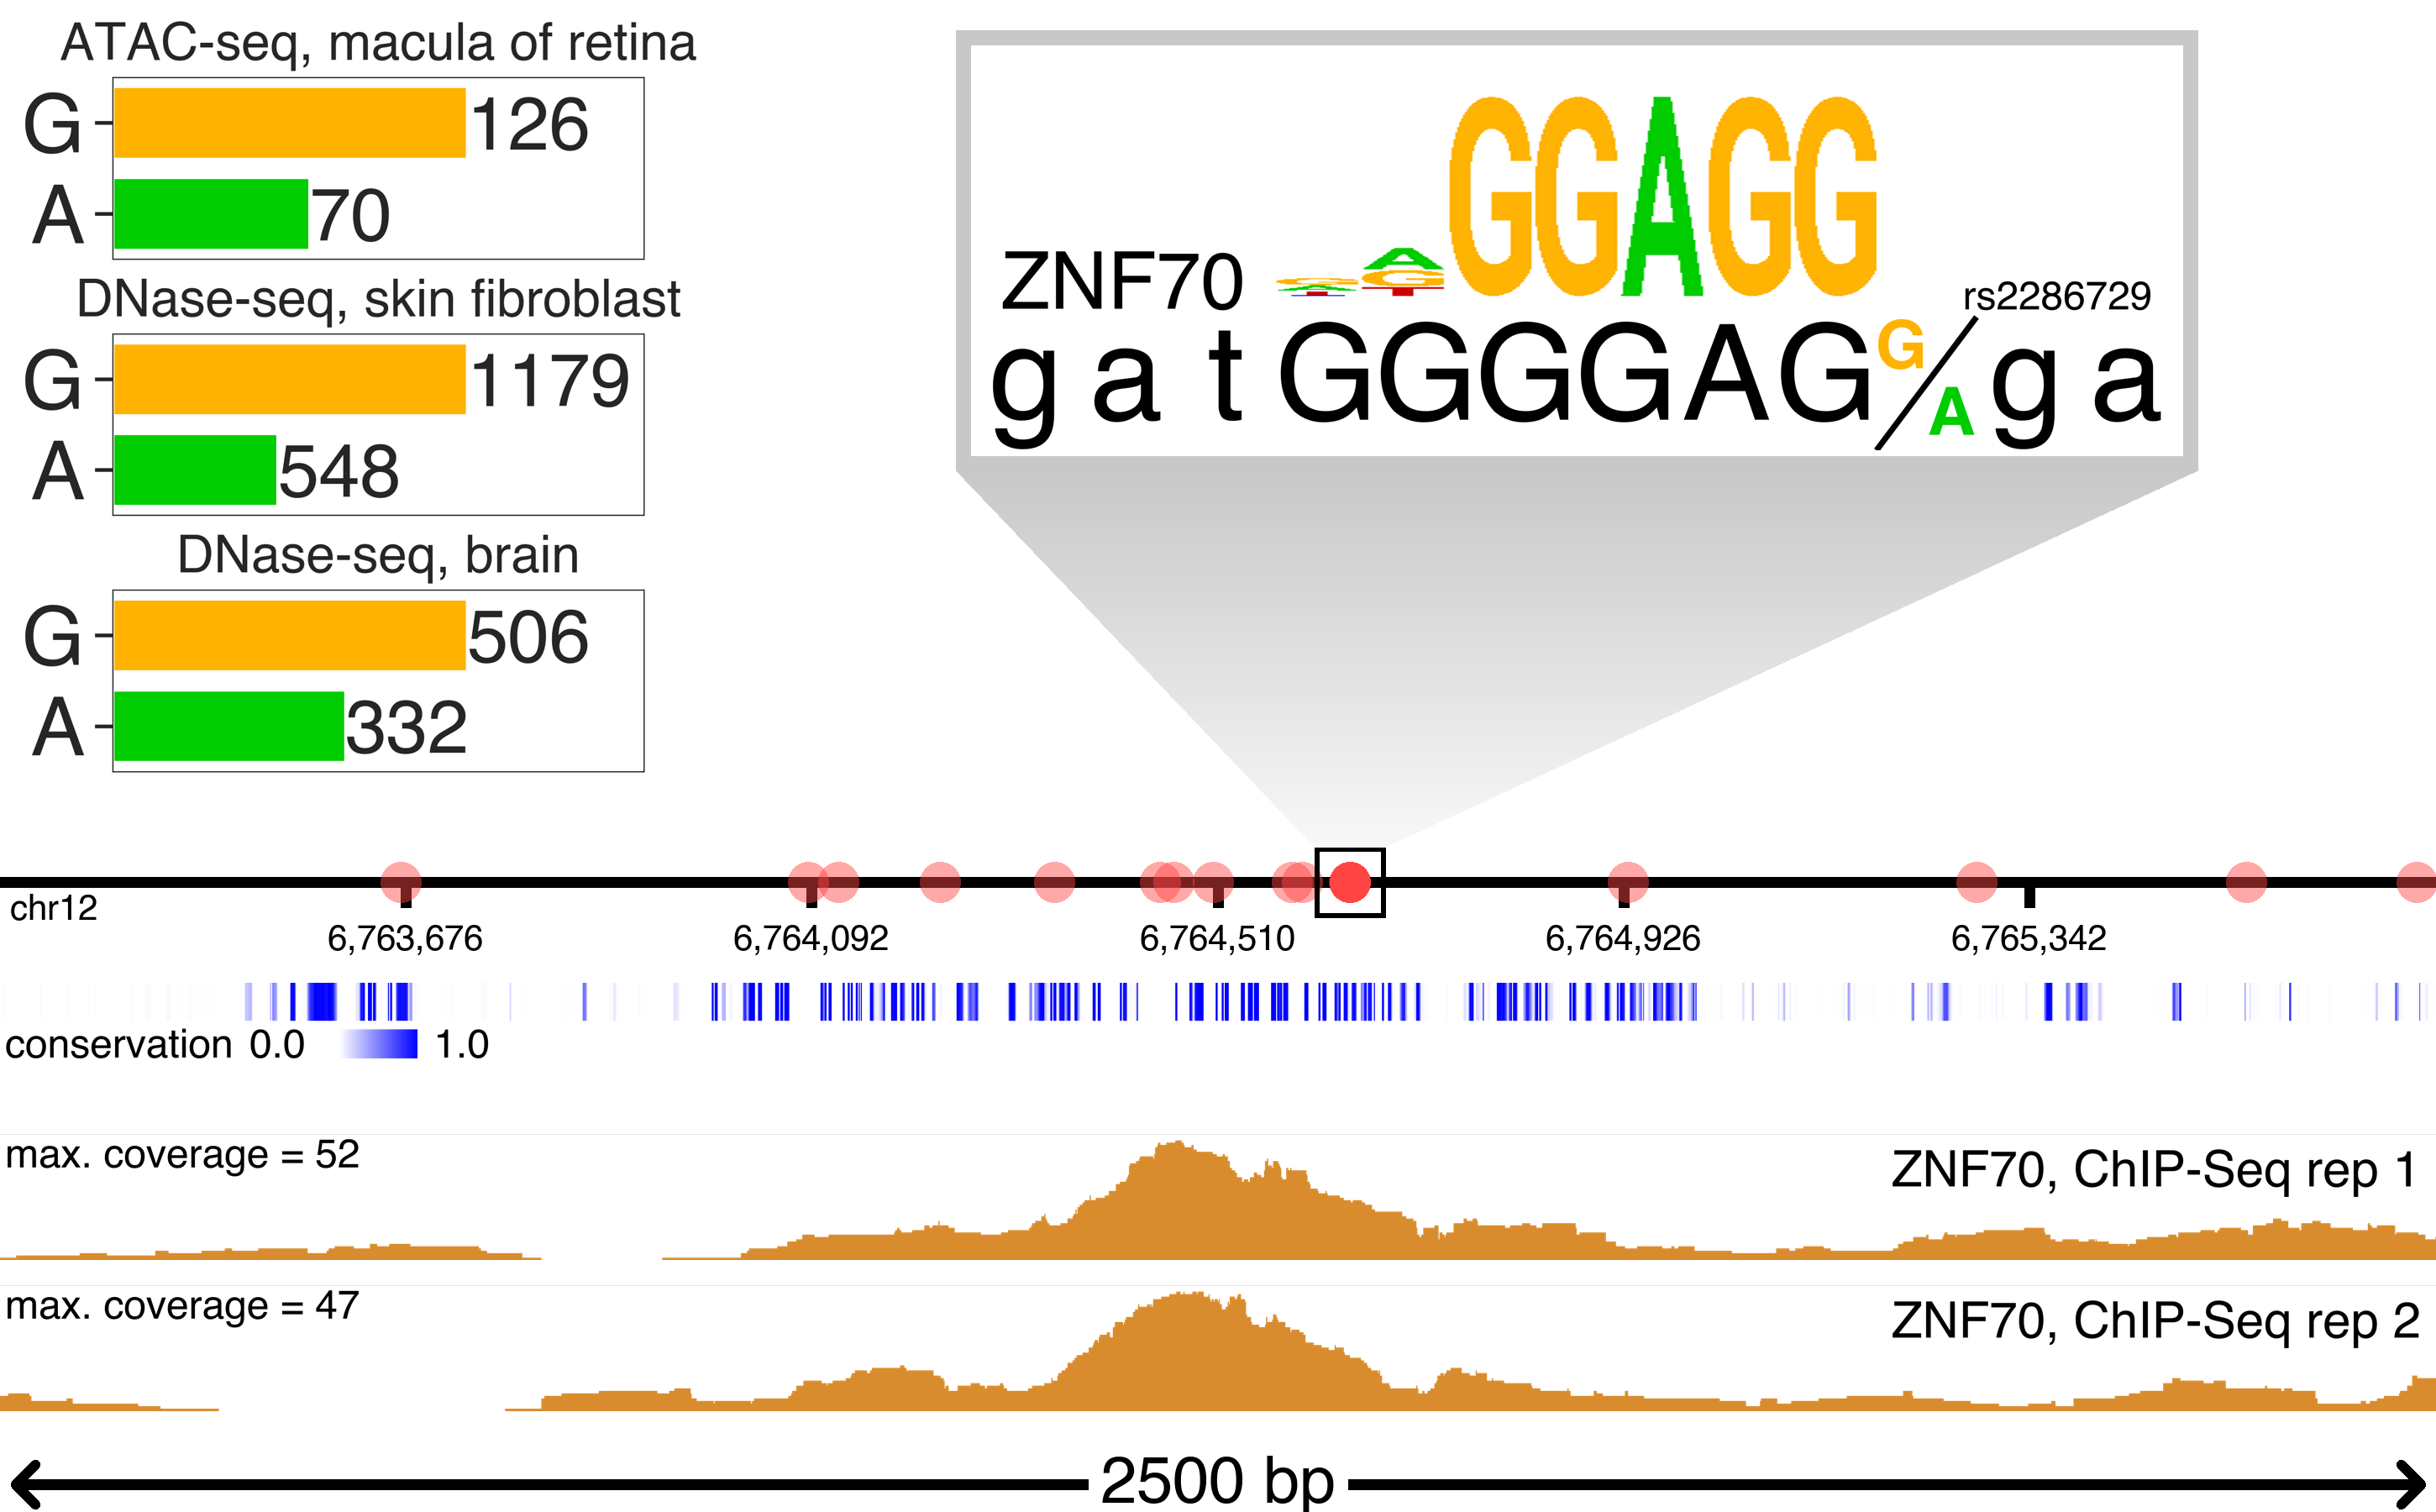

In [25]:
this_palette = ['#8FCF98', '#F9DC5C', '#C64191', '#1A5E63', '#028090']

def circle(xy, r, draw, **kwargs):
    x, y = xy
    x1, y1 = x - r, y - r
    x2, y2 = x + r, y + r
    draw.ellipse(((x1, y1), (x2, y2)), **kwargs)

def round_line(xy, draw, **kwargs):
    p1, p2 = xy
    draw.line((p1, p2, p1, p2), **kwargs)

def sample_title(title):
    title = title.split('.')
    return f'{title[0]}, {title[1]} ChIP-Seq'


def interpolator(f_co, t_co, interval, func):
    det_co = [func((t - f) / interval) for f , t in zip(f_co, t_co)]
    for i in range(interval):
        yield [round(f + det * i) for f, det in zip(f_co, det_co)]

def gradient(size, **kwargs):
    top_color = kwargs['top_color']
    bot_color = kwargs['bot_color']
    img = Image.new('RGBA', size)
    draw = ImageDraw.Draw(img)
    interpolation = interpolator(top_color, bot_color, img.height * 2, func=lambda x: x**0.8)
    for i, color in enumerate(interpolation):
        draw.line([(0, i), (img.width, i)], tuple(color), width=1)
    return img

def draw_coverage(table, title, size, tick_w):
    W, H = size
    coef = 5
    w, h = W*coef, H*coef
    tick_w *= coef
    region_width = len(table)
    bar_width = round(w/region_width)
    img = Image.new('RGBA', (w, h))
    draw = ImageDraw.Draw(img)

    max_height = table['coverage'].max()

    draw.rectangle(((0, 0), (w, bar_width//2)), fill='#' + ('DD'*3))
    for i, row in table.iterrows():
        x1 = i*bar_width
        y1 = h - round(row['coverage']/max_height * h * 0.95)
        x2 = x1 + bar_width
        y2 = h
        bbox = [(x1, y1), (x2, y2)]
        draw.rectangle(bbox, fill='#D88C2D')
    font = ImageFont.truetype(f'/home/vladimirnoz/Projects/Codebook_Perspectives/fonts/Helvetica.ttf', size=tick_w*10)
    text_w = font.getlength(title)
    text_y = tick_w * 3
    text_x = w - tick_w*3
    draw.text((int(text_x), int(text_y)), title, font=font, fill='black', anchor='rt')

    font = ImageFont.truetype(f'/home/vladimirnoz/Projects/Codebook_Perspectives/fonts/Helvetica.ttf', size=tick_w*8)
    text_y = tick_w
    text_x = tick_w
    text_text = f'max. coverage = {max_height}'
    draw.text((int(text_x), int(text_y)), text_text, font=font, fill='black', anchor='lt')
    
    return img.resize(size)

def hex_to_rgb_array(hex_color):
    """
    Convert a hexadecimal color code to a NumPy array of RGB values.
    
    :param hex_color: A string representing the hex color code (e.g., "#DC143C")
    :return: A NumPy array of integers representing RGB values (0-255)
    """
    # Remove the '#' if it's present
    hex_color = hex_color.lstrip('#')
    
    # Convert the hex string to RGB values
    rgb = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    
    # Return as a NumPy array
    return np.array(rgb, dtype=np.uint8)

def rgb_array_to_hex(rgb_array):
    """
    Convert a NumPy array of RGB values to a hexadecimal color code.
    
    :param rgb_array: A NumPy array of integers representing RGB values (0-255)
    :return: A string representing the hex color code (e.g., "#DC143C")
    """
    # Ensure the input is a NumPy array
    rgb_array = np.asarray(rgb_array, dtype=np.uint8)
    
    # Check if the array has the correct shape
    if rgb_array.shape != (3,):
        raise ValueError("Input array must have shape (3,)")
    
    # Convert the array to hexadecimal
    hex_color = '#{:02X}{:02X}{:02X}'.format(*rgb_array)
    
    return hex_color


def get_cons_color(palette, score, half=0.5):
    bot, white, top = palette
    bot, top = white, top
    res = bot*(1-score) + top*score
    return rgb_array_to_hex(res)

def concatenate_images_horizontally(image1, image2):
    total_width = image1.size[0] + image2.size[0]
    max_height = image1.size[1]
    
    new_image = Image.new('RGBA', (total_width, max_height))
    new_image.paste(image1, (0, 0))
    new_image.paste(image2, (image1.size[0], 0))
    
    return new_image



def draw_conservation(table, title, size, tick_w):
    W, H = size
    coef = 5
    w, h = W*coef, H*coef
    tick_w *= coef
    region_width = len(table)
    bar_width = round(w/region_width)
    img = Image.new('RGBA', (w, h))
    draw = ImageDraw.Draw(img)

    max_height = max(table)

    cons_palette = ["#FF0000", "#FFFFFF", "#0000FF"]
    cons_palette = [hex_to_rgb_array(col) for col in cons_palette]

    draw.rectangle(((0, 0), (w, bar_width//2)), fill='#DDD')
    for i, score in enumerate(table):
        x1 = i*bar_width
        y1 = 0
        x2 = x1 + bar_width
        y2 = h*0.3
        bbox = [(x1, y1), (x2, y2)]
        draw.rectangle(bbox, fill=get_cons_color(cons_palette, score))
    
    font = ImageFont.truetype(f'/home/vladimirnoz/Projects/Codebook_Perspectives/fonts/Helvetica.ttf', size=tick_w*8)
    text_y = h - int(tick_w * 10)
    text_x = tick_w
    text_text = f'conservation '
    text_w = int(font.getlength(text_text))
    text_box = font.getbbox(text_text)
    draw.text((int(text_x), int(text_y)), text_text, font=font, fill='black', anchor='lb')

    text_x = text_x + text_w + tick_w
    text_text = f'0.0 '
    text_w = int(font.getlength(text_text))
    text_box = font.getbbox(text_text)
    draw.text((int(text_x), int(text_y)), text_text, font=font, fill='black', anchor='lb')

    print(text_box)
    #grad1 = gradient((h, w), top_color=cons_palette[0], bot_color=cons_palette[1]).rotate(90, expand=True)
    grad2 = gradient((h, w), top_color=cons_palette[-1], bot_color=cons_palette[1]).rotate(-90, expand=True)
    #grad = concatenate_images_horizontally(grad1, grad2)
    grad = grad2
    grad_w = tick_w*20
    grad_h = text_box[-1] - text_box[1]
    img.paste(grad.resize((grad_w, grad_h)), (text_w + text_x, text_y - grad_h))

    text_x = text_x + text_w + tick_w + grad_w
    text_text = f' 1.0'
    text_w = int(font.getlength(text_text))
    text_box = font.getbbox(text_text)
    draw.text((int(text_x), int(text_y)), text_text, font=font, fill='black', anchor='lb')
    
    return img.resize(size)





w, h = 2900, 1800
coverage_image = Image.new('RGBA', (w, h))
draw = ImageDraw.Draw(coverage_image, mode='RGBA')
draw.rectangle((-100, -100, w+100, h+100), fill='white')

cov_w = w
cov_h = 150
tick_w = int(cov_h * 0.04)
for i, (key, item) in enumerate(reversed(coverage.items())):
    x, y = 0, h - (i+1)*cov_h*1.2 - tick_w*15
    сov_title = f'{tfname}, ChIP-Seq rep {2-i}'
    cov_img = draw_coverage(item, сov_title, (int(cov_w), int(cov_h)), tick_w)
    coverage_image.alpha_composite(cov_img, (int(x), int(y)))
    sample_name = key

x, y = 0, h - (i+2)*cov_h*1.2 - tick_w*15
cov_img = draw_conservation(conservation, сov_title, (int(cov_w), int(cov_h)), tick_w)
coverage_image.alpha_composite(cov_img, (int(x), int(y)))

axis_x1 = 0
axis_x2 = w
axis_y1 = h - cov_h*5
round_line(((int(axis_x1), int(axis_y1)), (int(axis_x2), int(axis_y1))), draw, fill='black', width=tick_w*2)

ticks = list(np.linspace(0, w, num=7, dtype=int))[1:-1]

positions = coverage[sample_name]['pos']
chrom = coverage[sample_name]['#chr'].iloc[0]

region_start = positions.min()
region_end = positions.max()
region_width = region_end - region_start + 1

font = ImageFont.truetype(f'/home/vladimirnoz/Projects/Codebook_Perspectives/fonts/Helvetica.ttf', size=int(tick_w*7))

draw.text([axis_x1+tick_w*2, axis_y1+tick_w*2], chrom, font=font, fill='black')

for tick in ticks:
    tick_x1 = int(tick - tick_w)
    tick_x2 = int(tick + tick_w)
    tick_h = tick_w * 5
    tick_y1 = int(axis_y1)
    tick_y2 = int(tick_y1 + tick_h)
    draw.rectangle(((tick_x1, tick_y1), (tick_x2, tick_y2)), fill='black')

    tick_text = int(tick/w * region_width + region_start)
    tick_text = f'{tick_text:,}'
    draw.text((tick, tick_y2 + tick_w*3), tick_text, font=font, anchor='ma', fill='black')

line_x1 = axis_x1 + tick_w*3
line_x2 = axis_x2 - tick_w*3
line_y1 = int(h - tick_w*5.5)
line_y2 = line_y1

round_line(((line_x1, line_y1), (line_x2, line_y2)), draw, fill='black', width=tick_w*2, joint='curve')
round_line([(line_x1, line_y1), (line_x1+tick_w*4, line_y1+tick_w*4)], draw, fill='black', width=tick_w*2, joint='curve')
round_line([(line_x1, line_y1), (line_x1+tick_w*4, line_y1-tick_w*4)], draw, fill='black', width=tick_w*2, joint='curve')
round_line([(line_x2, line_y2), (line_x2-tick_w*4, line_y2+tick_w*4)], draw, fill='black', width=tick_w*2, joint='curve')
round_line([(line_x2, line_y2), (line_x2-tick_w*4, line_y2-tick_w*4)], draw, fill='black', width=tick_w*2, joint='curve')
bp_text = f'{region_width} bp'

font = ImageFont.truetype(f'/home/vladimirnoz/Projects/Codebook_Perspectives/fonts/Helvetica.ttf', size=int(tick_w*13))
bp_bbox = font.getbbox(bp_text)
bp_w2 = bp_bbox[-2]*0.5
bp_h2 = bp_bbox[-1]*0.5
bp_bbox = (bp_bbox[0] - bp_w2, bp_bbox[1] - bp_h2, bp_bbox[2] - bp_w2, bp_bbox[3] - bp_h2)
bp_bbox = [int(bp_c*1.1) for bp_c in bp_bbox]
bp_coords = [ticks[2], line_y1]
bp_x, bp_y = bp_coords
draw.rectangle([bp_bbox[0] + bp_x, bp_bbox[1] + bp_y, bp_bbox[2] + bp_x, bp_bbox[3] + bp_y], fill='white')
draw.text(bp_coords, bp_text, font=font, fill='black', anchor='mm')

snp_pos = int(pos.split('\t')[-1])-6
snp_x = int((snp_pos - region_start)/region_width * w)
snp_y = axis_y1


for motif_hit_pos in motif_hits:
    overlay = Image.new('RGBA', (w, h))
    overlay_draw = ImageDraw.Draw(overlay)
    circle((motif_hit_pos/region_width*w, snp_y), tick_w*4, overlay_draw, fill='#FF444477')
    coverage_image.alpha_composite(overlay)
circle((snp_x, snp_y), tick_w*4, draw, fill='#FF4444')

snp_rect_x1 = snp_x - tick_w * 7
snp_rect_x2 = snp_x + tick_w * 7
snp_rect_y1 = snp_y - tick_w * 7
snp_rect_y2 = snp_y + tick_w * 7
draw.rectangle([snp_rect_x1, snp_rect_y1, snp_rect_x2, snp_rect_y2], outline='black', width=tick_w)

barplots_image = Image.open(barplots)
barplots_H = axis_y1*0.9
barplots_W = barplots_image.size[0]/barplots_image.size[1] * barplots_H
barplots_image = barplots_image.resize((int(barplots_W), int(barplots_H)))

motif_img = main_img.copy()
motif_w = (w - barplots_W)*0.7
motif_h = motif_w / motif_img.size[0] * motif_img.size[1]
motif_img = motif_img.resize([int(motif_w), int(motif_h)])

motif_img_pos = [int((barplots_W + (w - barplots_W - motif_w)/2)), tick_w*10]
motif_padding = tick_w*4

motif_bbox = [
    motif_img_pos[0] - motif_padding, 
    motif_img_pos[1] - motif_padding, 
    motif_img_pos[0] + motif_w + motif_padding, 
    motif_img_pos[1] + motif_h + motif_padding
]

line_coords = [
    (motif_bbox[0], motif_bbox[3]), 
    (snp_rect_x1, snp_rect_y1),
    (snp_rect_x2, snp_rect_y1),
    (motif_bbox[2], motif_bbox[3]),
]

line_coords = tuple(tuple(int(x) for x in p) for p in line_coords)


gradient_bbox = [
    min(line_coords, key=lambda p: p[0])[0],
    min(line_coords, key=lambda p: p[1])[1],
    max(line_coords, key=lambda p: p[0])[0],
    max(line_coords, key=lambda p: p[1])[1]
]

gradient_size = (gradient_bbox[2] - gradient_bbox[0], gradient_bbox[3] - gradient_bbox[1])

top_color = (200,)*3
bot_color = (255,)*3
gradient_img = gradient(gradient_size, top_color=top_color, bot_color=bot_color)
gradient_img_big = Image.new('RGBA', (w, h))
gradient_img_big.paste(gradient_img, tuple(gradient_bbox[:2]))
#coverage_image.alpha_composite(gradient_img, tuple(gradient_bbox[:2]))
gradient_mask = Image.new('RGBA', (w, h))
gradient_mask_draw = ImageDraw.Draw(gradient_mask)
#gradient_mask_draw.rectangle([-100, -100, w + 100, h +100], fill='black')
gradient_mask_draw.polygon(line_coords, fill='white')

coverage_image.paste(gradient_img_big, (0, 0), mask=gradient_mask)

#draw.line(line_coords, width=tick_w, fill='black', joint='curve')

coverage_image.alpha_composite(motif_img, tuple(motif_img_pos))
draw.rectangle(motif_bbox, outline=top_color, width=tick_w*3)



coverage_image.alpha_composite(barplots_image, (0, 0))

coverage_image.save('figures/snp_example.png', format='PNG')
coverage_image

In [ ]:
motif_w